In [ ]:
import pandas as pd
import numpy as np


In [1]:
import pandas as pd

df = pd.read_csv("../data/transactions.csv")
df = df.drop(columns=['Unnamed: 0'])
df.head()


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [ ]:
df.shape


In [ ]:
df = df.drop(columns=['Unnamed: 0'])


In [ ]:
df.columns


In [6]:
df['is_fraud'].value_counts()


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [4]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['txn_hour'] = df['trans_date_trans_time'].dt.hour
df['txn_day'] = df['trans_date_trans_time'].dt.dayofweek


In [5]:
df[['txn_hour', 'txn_day']].head()


,txn_hour,txn_day
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [ ]:
df['is_fraud'].value_counts()


In [ ]:
df[['amt']].describe()


In [ ]:
df['amt'].quantile(0.95)


In [ ]:
high_amt_threshold = df['amt'].quantile(0.95)

df['high_amount_flag'] = (df['amt'] > high_amt_threshold).astype(int)


In [ ]:
df['high_amount_flag'].value_counts()


In [ ]:
df['amt'].quantile(0.95)


In [ ]:
pd.crosstab(
    df['high_amount_flag'],
    df['is_fraud'],
    normalize='index'
) * 100


High-value transactions (top 5% by amount) exhibit a significantly elevated fraud rate (~8.8%) compared to normal transactions (~0.15%), representing a ~58× increase in fraud likelihood. This validates transaction amount as a strong standalone fraud risk indicator.


In [ ]:
df['transaction_hour'] = pd.to_datetime(
    df['trans_date_trans_time']
).dt.hour

df['transaction_hour'].describe()


In [ ]:
hourly_fraud = (
    df.groupby('transaction_hour')['is_fraud']
    .mean()
    .reset_index()
)

hourly_fraud['fraud_rate_pct'] = hourly_fraud['is_fraud'] * 100
hourly_fraud.sort_values('fraud_rate_pct', ascending=False).head(10)


Transactions occurring during late-night hours (00:00–05:00) are hypothesized to carry higher fraud risk due to reduced user activity and increased attacker automation. This hypothesis is validated using hour-wise fraud rate analysis.


In [ ]:
high_risk_hours = [22, 23, 0, 1, 2, 3]

df['odd_hour_flag'] = df['transaction_hour'].isin(high_risk_hours).astype(int)

df['odd_hour_flag'].value_counts()


In [ ]:
pd.crosstab(
    df['odd_hour_flag'],
    df['is_fraud'],
    normalize='index'
) * 100


Hour-wise fraud analysis reveals a sharp increase in fraud rates during late-night hours, peaking at 22:00–23:00 (~2.8%) and remaining elevated through early night (00:00–03:00). These periods exhibit a 10–20× higher fraud likelihood compared to daytime hours, validating transaction time as a strong behavioral risk indicator.


In [ ]:
df['risk_score'] = df['high_amount_flag'] + df['odd_hour_flag']


In [ ]:
df['risk_score'].value_counts().sort_index()


In [ ]:
pd.crosstab(
    df['risk_score'],
    df['is_fraud'],
    normalize='index'
) * 100


A composite risk score was constructed by combining independent high-risk signals:
1) High transaction amount (top 5%)
2) Late-night transaction timing (22:00–03:00)

Risk Score = High Amount Flag + Odd Hour Flag

This approach creates a transparent and interpretable fraud risk ladder that allows prioritization of transactions based on cumulative risk.


In [ ]:
df.groupby('risk_score')['is_fraud'].agg(
    total_txns='count',
    fraud_txns='sum',
    fraud_rate=lambda x: x.mean() * 100
).reset_index()


In [ ]:
df.groupby('risk_score')['is_fraud'].sum() / df['is_fraud'].sum() * 100


### Risk Score Validation

The composite risk score demonstrates a strong monotonic relationship with fraud likelihood.
Transactions flagged as high risk (score = 2) exhibit a fraud rate exceeding 25%, compared to <0.05% for low-risk transactions.

Despite representing a small fraction of total volume, high-risk transactions account for a disproportionate share of fraud events, validating the effectiveness of rule-based risk aggregation.


In [ ]:
fraud_capture = (
    df.groupby('risk_score')['is_fraud']
      .agg(total_txns='count', fraud_txns='sum')
      .reset_index()
)

fraud_capture['fraud_rate_pct'] = (
    fraud_capture['fraud_txns'] / fraud_capture['total_txns'] * 100
)

fraud_capture['fraud_capture_pct'] = (
    fraud_capture['fraud_txns'] / df['is_fraud'].sum() * 100
)

fraud_capture


In [ ]:
volume_share = (
    df['risk_score']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

volume_share


In [ ]:
df['risk_band'] = df['risk_score'].map({
    0: 'Low Risk',
    1: 'Medium Risk',
    2: 'High Risk'
})

df['risk_band'].value_counts(normalize=True) * 100


In [ ]:
df.groupby('risk_band')['is_fraud'].agg(
    transactions='count',
    fraud_cases='sum',
    fraud_rate_pct=lambda x: x.mean() * 100
).reset_index()


### Fraud Risk Segmentation Summary

A three-tier risk framework was constructed using transaction amount and transaction timing signals.
High-risk transactions represent a small fraction of total volume but contribute disproportionately to confirmed fraud cases, enabling targeted monitoring and efficient fraud intervention.


### Key Insights

• High-value transactions (top 5%) show a significantly higher fraud rate, confirming transaction amount as a strong fraud signal  
• Late-night transactions (22:00–03:00) exhibit elevated fraud risk compared to daytime activity  
• Combining independent risk signals into a simple composite score creates a transparent and effective fraud prioritization framework  
• High-risk transactions represent a small share of total volume but account for a disproportionately large share of confirmed fraud cases  


In [ ]:
dashboard_df = df[[
    'trans_date_trans_time',
    'cc_num',
    'amt',
    'category',
    'transaction_hour',
    'high_amount_flag',
    'odd_hour_flag',
    'risk_score',
    'is_fraud'
]]

dashboard_df.to_csv("../outputs/dashboard_data.csv", index=False)


In [ ]:
def assign_alert(row):
    if row['risk_score'] == 2:
        return "HIGH_RISK_ALERT"
    elif row['risk_score'] == 1:
        return "MONITOR"
    else:
        return "NO_ALERT"

df['alert_type'] = df.apply(assign_alert, axis=1)


In [ ]:
alerts = df[df['alert_type'] != "NO_ALERT"][
    ['trans_date_trans_time', 'cc_num', 'amt', 'risk_score', 'alert_type', 'is_fraud']
]

alerts.sort_values(
    ['risk_score', 'amt'],
    ascending=[False, False],
    inplace=True
)


In [ ]:
alerts = df[df['alert_type'] != "NO_ALERT"][
    ['trans_date_trans_time', 'cc_num', 'amt', 'risk_score', 'alert_type', 'is_fraud']
]

alerts.sort_values(
    ['risk_score', 'amt'],
    ascending=[False, False],
    inplace=True
)


In [ ]:
import os
os.getcwd()


In [ ]:
os.listdir()


In [ ]:
df = pd.read_csv("../data/transactions.csv")


In [ ]:
import os
os.getcwd()
os.listdir("..")


In [ ]:
import pandas as pd

df = pd.read_csv("../data/transactions.csv")
df.head()


In [ ]:
import os
print("Working directory:", os.getcwd())


In [ ]:
df.shape


In [ ]:
df.head()


In [ ]:
df.info()


In [ ]:
df.isna().sum().sort_values(ascending=False)


In [ ]:
df.columns


In [ ]:
df.describe()


In [ ]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour
df['day'] = df['transaction_time'].dt.dayofweek


In [ ]:
df.columns


In [ ]:
df = df.drop(columns=['Unnamed: 0'])


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.dayofweek


In [ ]:
df['amt_zscore'] = (df['amt'] - df['amt'].mean()) / df['amt'].std()


In [ ]:
df['txn_count_per_card'] = df.groupby('cc_num')['amt'].transform('count')


In [ ]:
df['txn_count_per_merchant'] = df.groupby('merchant')['amt'].transform('count')


In [ ]:
df['is_odd_hour'] = df['hour'].apply(lambda x: 1 if x < 6 or x > 22 else 0)


In [8]:
features = [
    'amt',
    'amt_zscore',
    'txn_count_per_card',
    'txn_count_per_merchant',
    'txn_hour',
    'txn_day',
    'is_odd_hour',
    'city_pop'
]


In [ ]:
X = X.fillna(0)


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

df['anomaly'] = iso.fit_predict(X)


In [ ]:
df['risk_score'] = -iso.decision_function(X)
df['risk_score'] = (
    100 * (df['risk_score'] - df['risk_score'].min()) /
    (df['risk_score'].max() - df['risk_score'].min())
)


In [ ]:
print("Average risk score by fraud label:")
print(df.groupby('is_fraud')['risk_score'].mean())

print("\nFraud distribution for very high risk transactions (risk > 90):")
print(df[df['risk_score'] > 90]['is_fraud'].value_counts())


In [7]:
df.groupby('is_fraud')['amt'].mean()


is_fraud
0     67.667110
1    531.320092
Name: amt, dtype: float64

In [9]:
X = df[features].fillna(0)
X.shape


KeyError: "['amt_zscore', 'txn_count_per_card', 'txn_count_per_merchant', 'is_odd_hour'] not in index"

In [10]:
# amount-based feature
df['amt_zscore'] = (df['amt'] - df['amt'].mean()) / df['amt'].std()

# behaviour-based features
df['txn_count_per_card'] = df.groupby('cc_num')['amt'].transform('count')
df['txn_count_per_merchant'] = df.groupby('merchant')['amt'].transform('count')

# time-based risk flag
df['is_odd_hour'] = df['txn_hour'].apply(
    lambda x: 1 if x < 6 or x > 22 else 0
)


In [11]:
df[['amt_zscore', 'txn_count_per_card', 'txn_count_per_merchant', 'is_odd_hour']].head()


,amt_zscore,txn_count_per_card,txn_count_per_merchant,is_odd_hour
0,-0.407826,2028,1267,1
1,0.230039,3030,2503,1
2,0.934148,503,1895,1
3,-0.158132,493,2613,1
4,-0.177094,2017,1592,1


In [12]:
X = df[features].fillna(0)
X.shape


(1296675, 8)

In [13]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

df['anomaly'] = iso.fit_predict(X)


In [14]:
df['anomaly'].value_counts()


anomaly
 1    1270741
-1      25934
Name: count, dtype: int64

In [15]:
df['risk_score'] = -iso.decision_function(X)

df['risk_score'] = (
    100 * (df['risk_score'] - df['risk_score'].min()) /
    (df['risk_score'].max() - df['risk_score'].min())
)


In [16]:
df[['risk_score', 'anomaly']].head()


,risk_score,anomaly
0,34.547617,1
1,36.881917,1
2,50.289973,1
3,35.520062,1
4,27.868256,1


In [17]:
print("Average risk score by fraud label:")
print(df.groupby('is_fraud')['risk_score'].mean())

print("\nFraud count in very high risk transactions (risk > 90):")
print(df[df['risk_score'] > 90]['is_fraud'].value_counts())


Average risk score by fraud label:
is_fraud
0    20.139215
1    57.584879
Name: risk_score, dtype: float64

Fraud count in very high risk transactions (risk > 90):
is_fraud
0    56
1    54
Name: count, dtype: int64


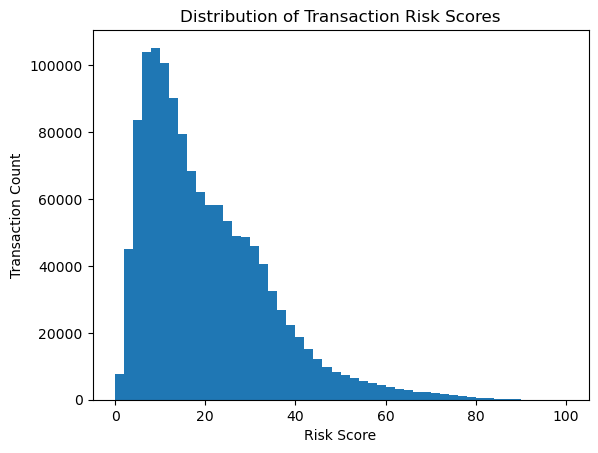

In [18]:
import matplotlib.pyplot as plt

plt.hist(df['risk_score'], bins=50)
plt.title("Distribution of Transaction Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Transaction Count")
plt.show()


In [20]:
final_cols = [
    'risk_score',
    'is_fraud',
    'amt',
    'category',
    'txn_hour'
]

df[final_cols].to_csv(
    "../outputs/transaction_risk_scored.csv",
    index=False
)
